**#EDA**

In [2]:
import pandas as pd
import numpy as np

# Load the preprocessed dataset
df = pd.read_csv("../data/processed_data/solar_power_generation_preprocessed.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1123099, 13)

Columns:
['CampusKey', 'SiteKey', 'Timestamp', 'SolarGeneration', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']

First 5 Rows:


,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,Year,Month,Day,Hour,DayOfWeek
0,2,1,2020-01-01 06:15:00,0.135,13.973333,15.246667,9.146667,67.000000,2020,1,1,6,2
1,2,1,2020-01-01 06:30:00,0.465,13.800000,15.213333,9.166667,67.266667,2020,1,1,6,2
2,2,1,2020-01-01 06:45:00,1.039,13.693333,15.160000,9.260000,68.000000,2020,1,1,6,2
3,2,1,2020-01-01 07:00:00,1.673,13.826667,15.546667,9.446667,67.000000,2020,1,1,7,2
4,2,1,2020-01-01 07:15:00,2.560,14.360000,15.920000,9.606667,66.000000,2020,1,1,7,2



Data Types:
CampusKey                int64
SiteKey                  int64
Timestamp                  str
SolarGeneration        float64
ApparentTemperature    float64
AirTemperature         float64
DewPointTemperature    float64
RelativeHumidity       float64
Year                     int64
Month                    int64
Day                      int64
Hour                     int64
DayOfWeek                int64
dtype: object

Missing Values:
CampusKey              0
SiteKey                0
Timestamp              0
SolarGeneration        0
ApparentTemperature    0
AirTemperature         0
DewPointTemperature    0
RelativeHumidity       0
Year                   0
Month                  0
Day                    0
Hour                   0
DayOfWeek              0
dtype: int64


In [3]:
# Target variable analysis

print("Solar Generation Statistics:")
print(df["SolarGeneration"].describe())

print("\nAdditional Statistics:")
print("Mean   :", df["SolarGeneration"].mean())
print("Median :", df["SolarGeneration"].median())
print("Std    :", df["SolarGeneration"].std())
print("Min    :", df["SolarGeneration"].min())
print("Max    :", df["SolarGeneration"].max())

Solar Generation Statistics:
count    1.123099e+06
mean     7.027549e+00
std      1.146982e+01
min      1.000000e-01
25%      1.121094e+00
50%      3.289062e+00
75%      8.054688e+00
max      9.921880e+01
Name: SolarGeneration, dtype: float64

Additional Statistics:
Mean   : 7.027548604800607
Median : 3.2890625
Std    : 11.469815367279057
Min    : 0.1000000000058207
Max    : 99.21879999997329


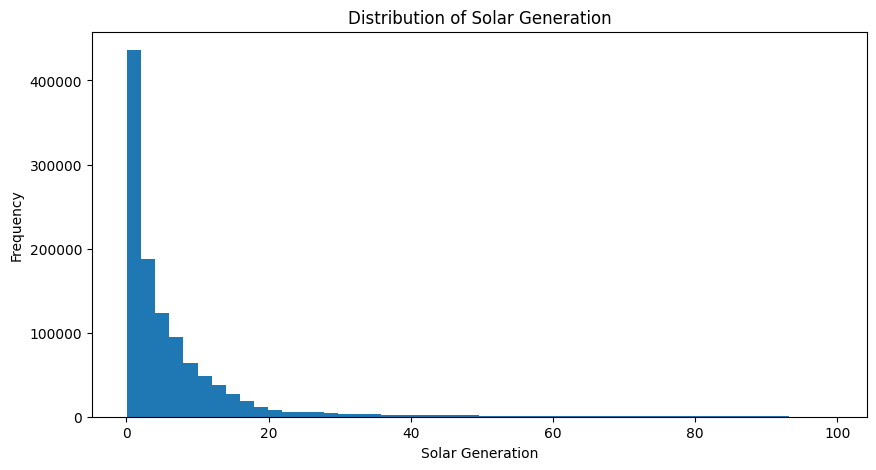

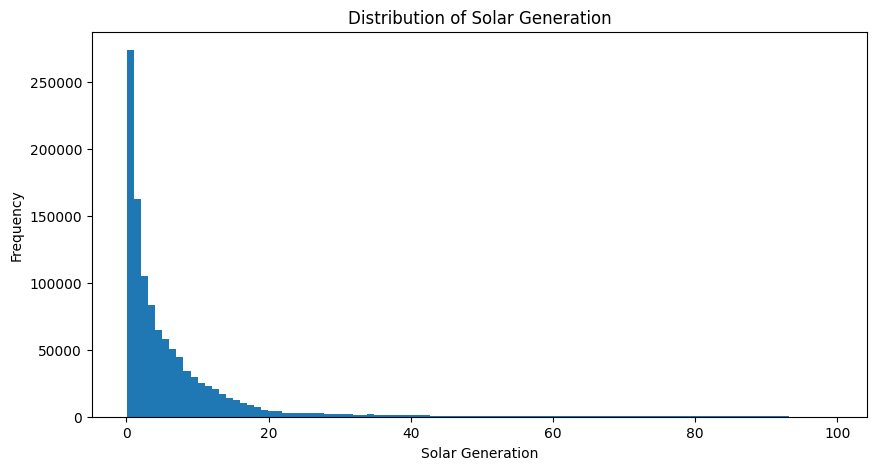

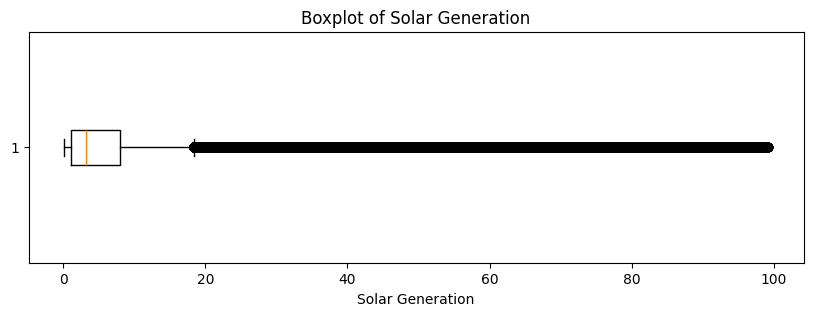

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["SolarGeneration"], bins=50)

plt.xlabel("Solar Generation")
plt.ylabel("Frequency")
plt.title("Distribution of Solar Generation")

plt.show()

plt.figure(figsize=(10, 5))

plt.hist(df["SolarGeneration"], bins=100)

plt.xlabel("Solar Generation")
plt.ylabel("Frequency")
plt.title("Distribution of Solar Generation")

plt.show()

plt.figure(figsize=(10, 3))

plt.boxplot(df["SolarGeneration"], vert=False)

plt.xlabel("Solar Generation")
plt.title("Boxplot of Solar Generation")

plt.show()

In [6]:
# Correlation of numerical features with SolarGeneration

correlation = df[
    [
        "SolarGeneration",
        "ApparentTemperature",
        "AirTemperature",
        "DewPointTemperature",
        "RelativeHumidity"
    ]
].corr()

print(correlation["SolarGeneration"].sort_values(ascending=False))

SolarGeneration        1.000000
AirTemperature         0.189149
ApparentTemperature    0.151720
DewPointTemperature   -0.030726
RelativeHumidity      -0.237294
Name: SolarGeneration, dtype: float64


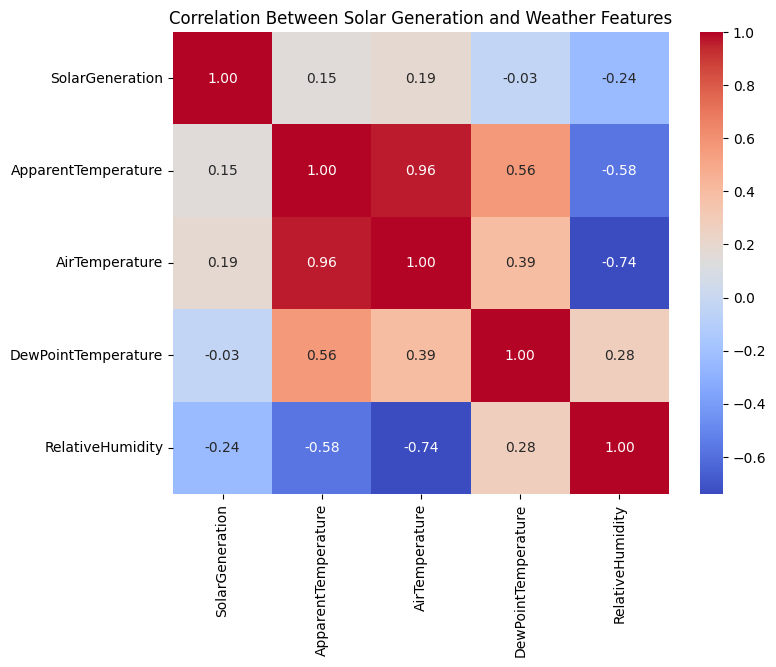

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

weather_features = [
    "SolarGeneration",
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[weather_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Solar Generation and Weather Features")
plt.show()

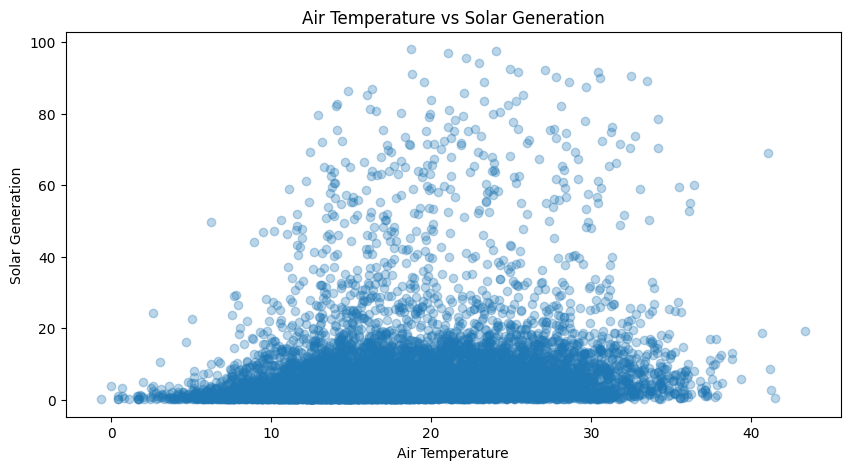

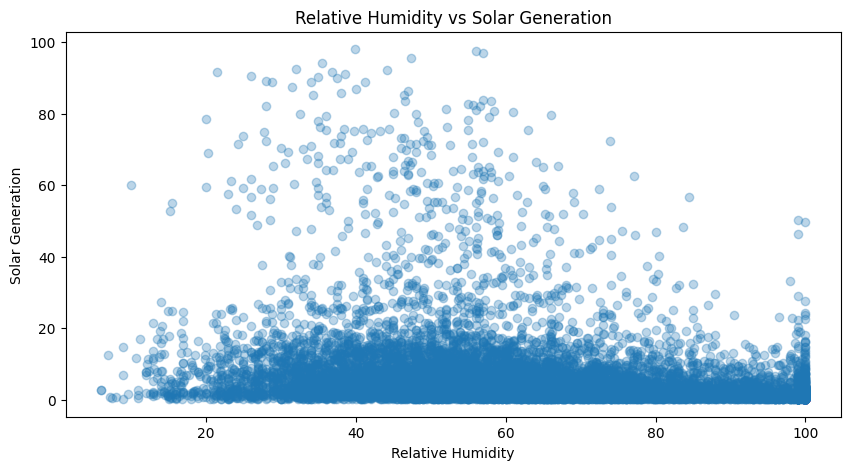

In [9]:
# Take a sample only for visualization
plot_df = df.sample(n=10000, random_state=42)

# Air Temperature vs Solar Generation
plt.figure(figsize=(10, 5))

plt.scatter(
    plot_df["AirTemperature"],
    plot_df["SolarGeneration"],
    alpha=0.3
)

plt.xlabel("Air Temperature")
plt.ylabel("Solar Generation")
plt.title("Air Temperature vs Solar Generation")

plt.show()

# Relative Humidity vs Solar Generation

plt.figure(figsize=(10, 5))

plt.scatter(
    plot_df["RelativeHumidity"],
    plot_df["SolarGeneration"],
    alpha=0.3
)

plt.xlabel("Relative Humidity")
plt.ylabel("Solar Generation")
plt.title("Relative Humidity vs Solar Generation")

plt.show()

    Hour  SolarGeneration
0      0         0.963216
1      1         0.313622
2      2         0.127804
3      3         0.125000
4      4         0.125000
5      5         0.125000
6      6         0.473888
7      7         1.228325
8      8         2.942572
9      9         5.836712
10    10         8.527632
11    11        10.223008
12    12        10.614278
13    13        10.313960
14    14         9.756125
15    15         8.793230
16    16         6.723500
17    17         5.406681
18    18         3.912256
19    19         1.537341
20    20         0.516933
21    21         0.589715
22    22         1.215631
23    23         0.927514


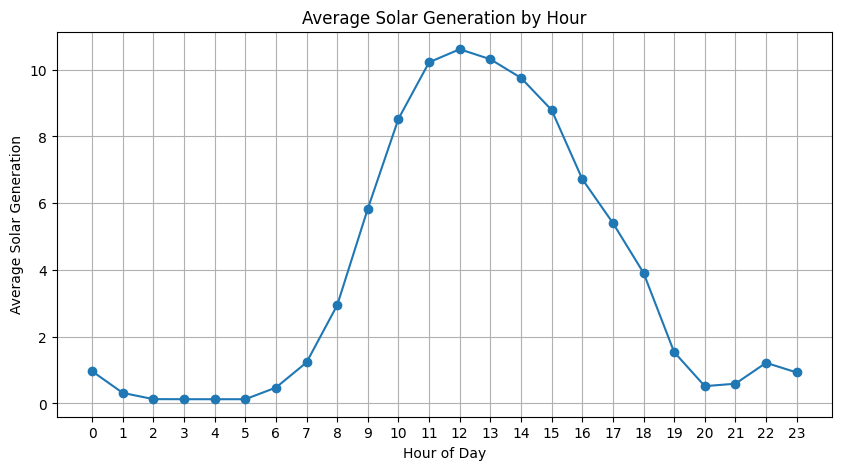

In [10]:
# Average solar generation by hour

hourly_generation = (
    df.groupby("Hour")["SolarGeneration"]
    .mean()
    .reset_index()
)

print(hourly_generation)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_generation["Hour"],
    hourly_generation["SolarGeneration"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Solar Generation")
plt.title("Average Solar Generation by Hour")

plt.xticks(range(0, 24))

plt.grid(True)
plt.show()

    Month  SolarGeneration
0       1         7.924450
1       2         8.612823
2       3         7.737593
3       4         6.156670
4       5         5.125571
5       6         3.933069
6       7         4.472264
7       8         6.039835
8       9         7.363272
9      10         7.505273
10     11         7.627048
11     12         7.926331


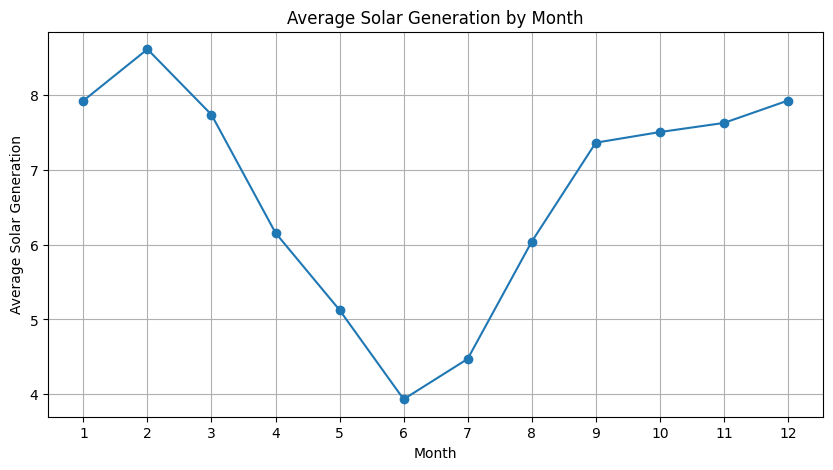

In [11]:
# Average solar generation by month

monthly_generation = (
    df.groupby("Month")["SolarGeneration"]
    .mean()
    .reset_index()
)

print(monthly_generation)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_generation["Month"],
    monthly_generation["SolarGeneration"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Solar Generation")
plt.title("Average Solar Generation by Month")

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()



   CampusKey  SolarGeneration
0          1         6.870113
1          2         5.722526
2          3         8.481118


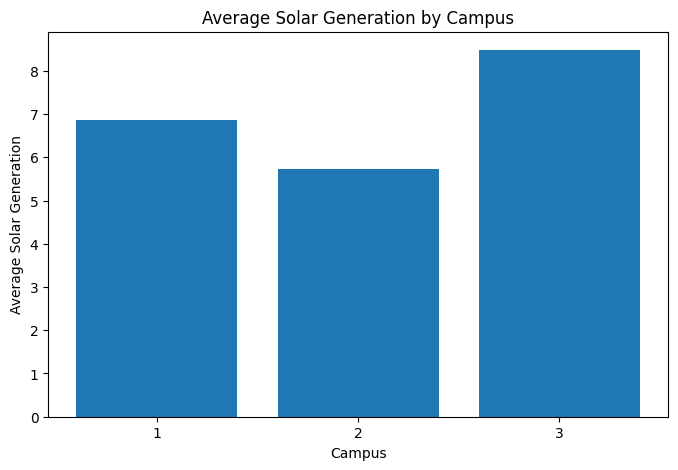

In [12]:
# Average solar generation by campus

campus_generation = (
    df.groupby("CampusKey")["SolarGeneration"]
    .mean()
    .reset_index()
)

print(campus_generation)

plt.figure(figsize=(8, 5))

plt.bar(
    campus_generation["CampusKey"].astype(str),
    campus_generation["SolarGeneration"]
)

plt.xlabel("Campus")
plt.ylabel("Average Solar Generation")
plt.title("Average Solar Generation by Campus")

plt.show()

**# TRAIN AND TEST**

**FEATURES : X(11 input features)**

CampusKey,
SiteKey,
ApparentTemperature,
AirTemperature,
DewPointTemperature,
RelativeHumidity,
Year,
Month,
Day,
Hour,
DayOfWeek

**TARGET VARIABLE : Y**

SolarGeneration

In [13]:
# Define features and target

feature_columns = [
    "CampusKey",
    "SiteKey",
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "Year",
    "Month",
    "Day",
    "Hour",
    "DayOfWeek"
]

X = df[feature_columns]
y = df["SolarGeneration"]

# Check the results
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

Features (X) shape: (1123099, 11)
Target (y) shape: (1123099,)

Feature columns:
['CampusKey', 'SiteKey', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']

First 5 rows of X:


,CampusKey,SiteKey,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,Year,Month,Day,Hour,DayOfWeek
0,2,1,13.973333,15.246667,9.146667,67.000000,2020,1,1,6,2
1,2,1,13.800000,15.213333,9.166667,67.266667,2020,1,1,6,2
2,2,1,13.693333,15.160000,9.260000,68.000000,2020,1,1,6,2
3,2,1,13.826667,15.546667,9.446667,67.000000,2020,1,1,7,2
4,2,1,14.360000,15.920000,9.606667,66.000000,2020,1,1,7,2



First 5 values of y:


0    0.135
1    0.465
2    1.039
3    1.673
4    2.560
Name: SolarGeneration, dtype: float64

In [14]:
# Check the timestamp ordering

timestamp_check = pd.to_datetime(df["Timestamp"])

print("First timestamp:", timestamp_check.min())
print("Last timestamp :", timestamp_check.max())

print("\nIs the dataset already chronologically sorted?")
print(timestamp_check.is_monotonic_increasing)

First timestamp: 2020-01-01 06:15:00
Last timestamp : 2022-04-23 17:45:00

Is the dataset already chronologically sorted?
False


In [15]:
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort the complete dataset chronologically
df = df.sort_values("Timestamp").reset_index(drop=True)

# Recreate X and y after sorting
X = df[feature_columns]
y = df["SolarGeneration"]

# Verify chronological order
print("First timestamp:", df["Timestamp"].iloc[0])
print("Last timestamp :", df["Timestamp"].iloc[-1])

print("\nIs the dataset chronologically sorted?")
print(df["Timestamp"].is_monotonic_increasing)

print("\nDataset shape:", df.shape)

First timestamp: 2020-01-01 06:15:00
Last timestamp : 2022-04-23 17:45:00

Is the dataset chronologically sorted?
True

Dataset shape: (1123099, 13)


In [16]:
# Chronological 80/20 train-test split

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Display split information
print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Check the time ranges
print("\nTraining period:")
print(df["Timestamp"].iloc[0], "→", df["Timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Timestamp"].iloc[split_index], "→", df["Timestamp"].iloc[-1])

Training set:
X_train: (898479, 11)
y_train: (898479,)

Testing set:
X_test: (224620, 11)
y_test: (224620,)

Training period:
2020-01-01 06:15:00 → 2021-12-21 19:15:00

Testing period:
2021-12-21 19:15:00 → 2022-04-23 17:45:00


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



In [20]:
# Linear Regression Model

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression trained successfully!")
print("First 10 predictions:")
print(y_pred_linear[:10])

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE  :", mae_linear)
print("MSE  :", mse_linear)
print("RMSE :", rmse_linear)
print("R²   :", r2_linear)

Linear Regression trained successfully!
First 10 predictions:
[ 6.4632214  10.06289141  7.85836734  6.21701918  7.65865483  7.03769326
  7.41245261  7.16625038  9.81668919  7.24831779]
Linear Regression Results
-------------------------
MAE  : 6.9273846663456675
MSE  : 143.28127479100593
RMSE : 11.970015655420251
R²   : 0.08460958839462362


In [22]:
# KNN Regression Model

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Regression trained successfully!")
print("First 10 predictions:")
print(y_pred_knn[:10])

# Evaluate KNN Regression

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression Results")
print("----------------------")
print("MAE  :", mae_knn)
print("MSE  :", mse_knn)
print("RMSE :", rmse_knn)
print("R²   :", r2_knn)

KNN Regression trained successfully!
First 10 predictions:
[1.57265625 2.215625   4.4828125  2.0640625  2.540625   0.59296875
 7.028125   6.621875   1.4015625  6.846875  ]
KNN Regression Results
----------------------
MAE  : 6.262396330121428
MSE  : 124.76690383931886
RMSE : 11.169910645986334
R²   : 0.20289355586211089


In [24]:
# Decision Tree Regression Model

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree Regression trained successfully!")
print("First 10 predictions:")
print(y_pred_dt[:10])

# Evaluate Decision Tree Regression

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Results")
print("--------------------------------")
print("MAE  :", mae_dt)
print("MSE  :", mse_dt)
print("RMSE :", rmse_dt)
print("R²   :", r2_dt)

Decision Tree Regression trained successfully!
First 10 predictions:
[ 2.09375    3.28125    2.875      2.09375    2.28125    0.421875
  0.8125     2.8125     0.3046875 18.       ]
Decision Tree Regression Results
--------------------------------
MAE  : 3.2457249677218702
MSE  : 48.35021441442055
RMSE : 6.953431844378756
R²   : 0.6911018363105541


In [25]:
# Random Forest Regression

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE  :", mae_rf)
print("MSE  :", mse_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

Random Forest Regression Results
--------------------------------
MAE  : 2.498314728859337
MSE  : 26.45240604730621
RMSE : 5.14319025968379
R²   : 0.8310017907440047


In [26]:
# Gradient Boosting Regression

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

# Evaluation
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regression Results")
print("------------------------------------")
print("MAE  :", mae_gb)
print("MSE  :", mse_gb)
print("RMSE :", rmse_gb)
print("R²   :", r2_gb)

Gradient Boosting Regression Results
------------------------------------
MAE  : 4.0150614259724335
MSE  : 50.32266843318681
RMSE : 7.093847223699338
R²   : 0.6785002908626595


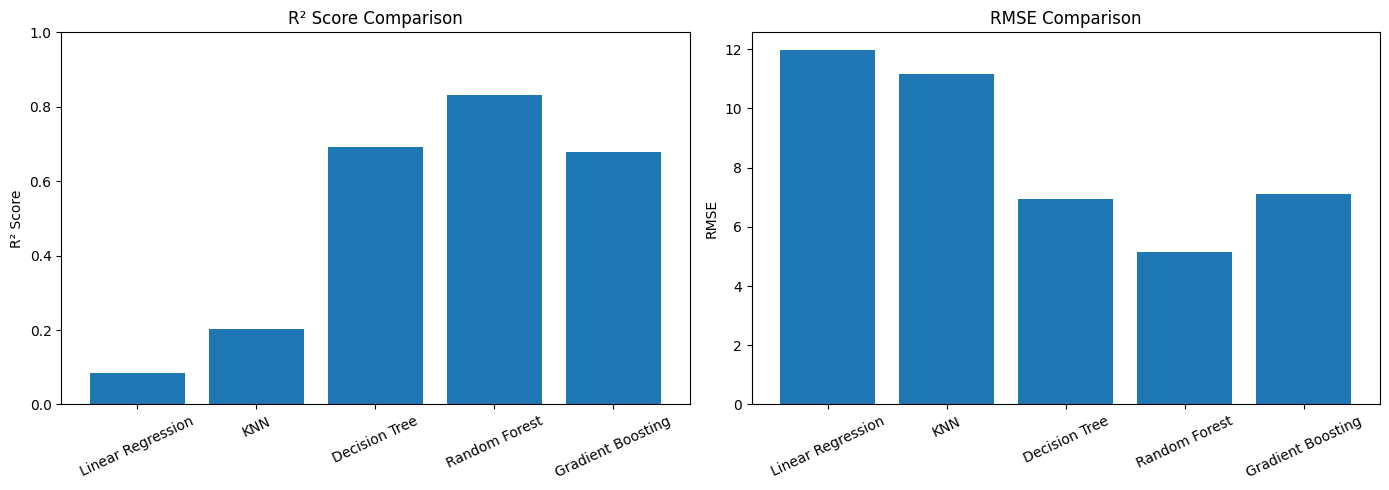

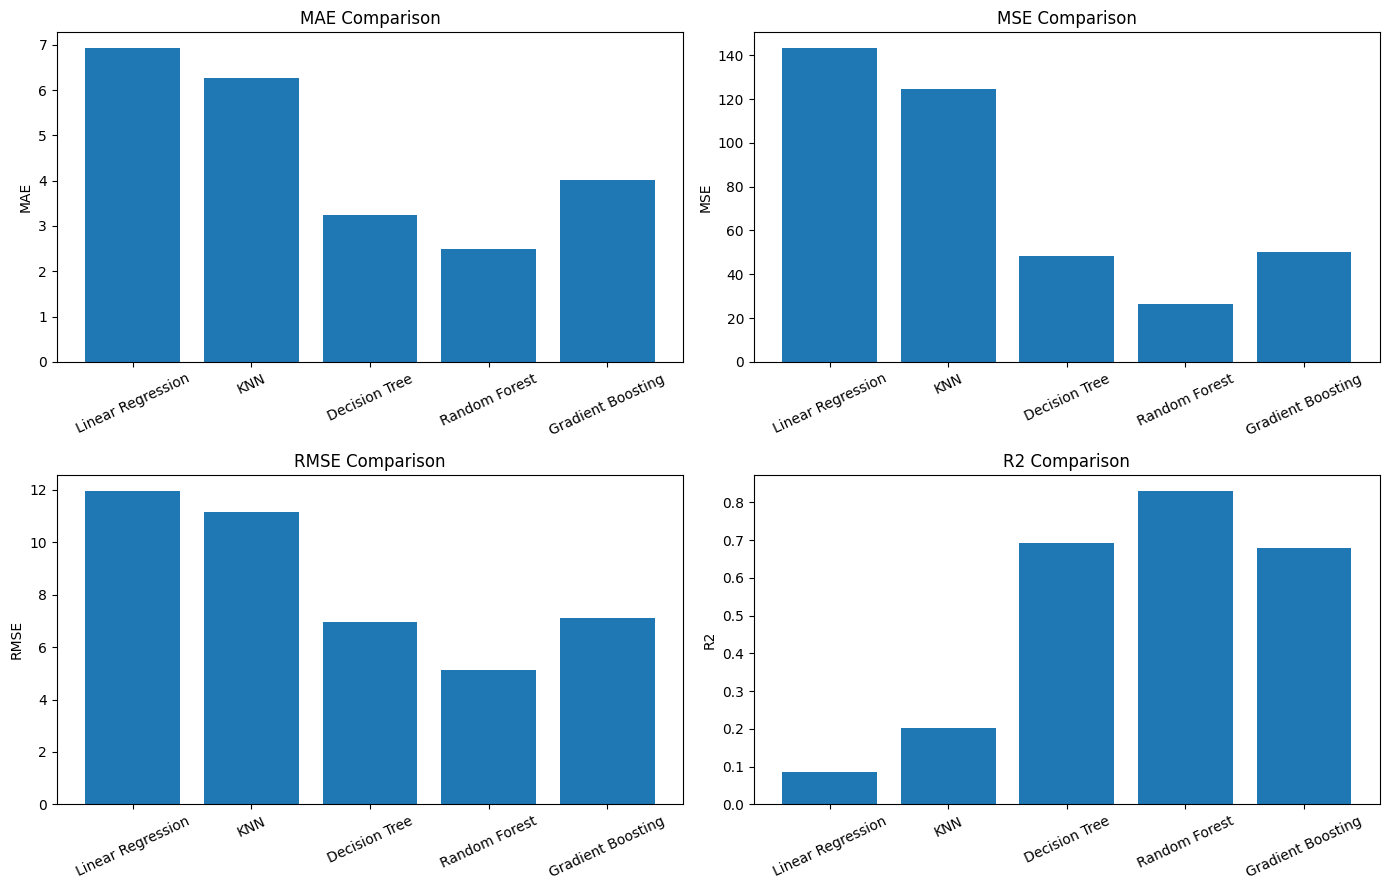

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Model results
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        6.9274,
        6.2624,
        3.2457,
        2.4983,
        4.0151
    ],
    "MSE": [
        143.2813,
        124.7669,
        48.3502,
        26.4524,
        50.3227
    ],
    "RMSE": [
        11.9700,
        11.1699,
        6.9534,
        5.1432,
        7.0938
    ],
    "R2": [
        0.0846,
        0.2029,
        0.6911,
        0.8310,
        0.6785
    ]
})

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² plot
axes[0].bar(results["Model"], results["R2"])
axes[0].set_title("R² Score Comparison")
axes[0].set_ylabel("R² Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)

# RMSE plot
axes[1].bar(results["Model"], results["RMSE"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = ["MAE", "MSE", "RMSE", "R2"]

for ax, metric in zip(axes.ravel(), metrics):
    ax.bar(results["Model"], results[metric])
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

                Feature  Importance
1               SiteKey    0.529044
9                  Hour    0.154285
5      RelativeHumidity    0.117858
7                 Month    0.049734
3        AirTemperature    0.042797
8                   Day    0.029828
2   ApparentTemperature    0.027477
4   DewPointTemperature    0.025199
10            DayOfWeek    0.015752
6                  Year    0.004080
0             CampusKey    0.003947


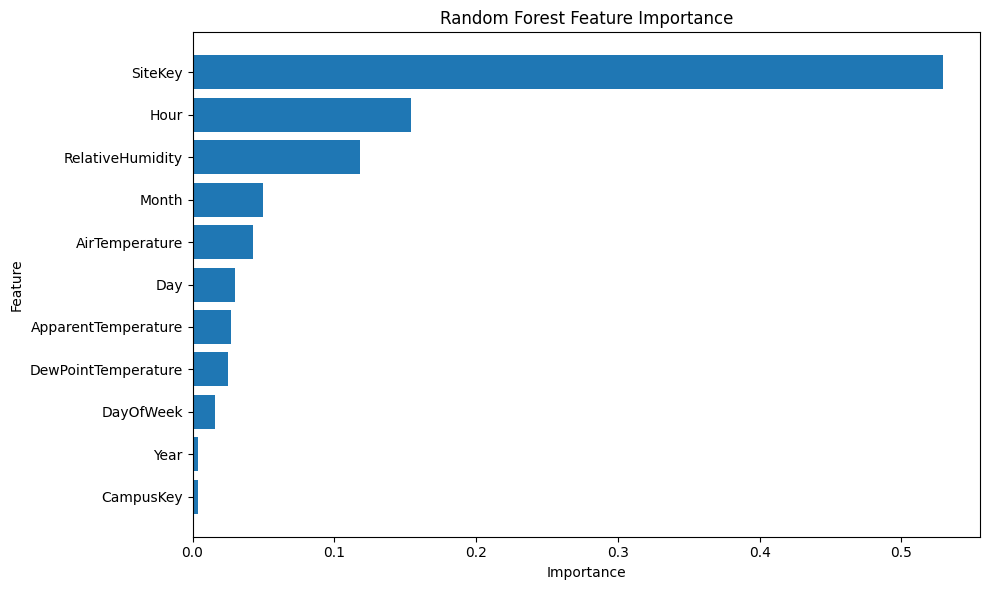

In [30]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
import numpy as np

df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df["DayOfWeek_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DayOfWeek_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

print(df[
    [
        "Hour",
        "Hour_sin",
        "Hour_cos",
        "Month",
        "Month_sin",
        "Month_cos",
        "DayOfWeek",
        "DayOfWeek_sin",
        "DayOfWeek_cos"
    ]
].head())

   Hour  Hour_sin      Hour_cos  Month  Month_sin  Month_cos  DayOfWeek  \
0     6       1.0  6.123234e-17      1        0.5   0.866025          2   
1     6       1.0  6.123234e-17      1        0.5   0.866025          2   
2     6       1.0  6.123234e-17      1        0.5   0.866025          2   
3     6       1.0  6.123234e-17      1        0.5   0.866025          2   
4     6       1.0  6.123234e-17      1        0.5   0.866025          2   

   DayOfWeek_sin  DayOfWeek_cos  
0       0.974928      -0.222521  
1       0.974928      -0.222521  
2       0.974928      -0.222521  
3       0.974928      -0.222521  
4       0.974928      -0.222521  


In [32]:
# Create improved feature set

improved_features = [
    "CampusKey",
    "SiteKey",
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "Year",
    "Day",

    # Cyclical time features
    "Hour_sin",
    "Hour_cos",
    "Month_sin",
    "Month_cos",
    "DayOfWeek_sin",
    "DayOfWeek_cos"
]

X_improved = df[improved_features]
y_improved = df["SolarGeneration"]

print("Features:", X_improved.columns.tolist())
print("Shape:", X_improved.shape)

Features: ['CampusKey', 'SiteKey', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity', 'Year', 'Day', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos']
Shape: (1123099, 14)


In [33]:
# Chronological 80/20 split for improved features

split_index = int(len(df) * 0.80)

X_train_improved = X_improved.iloc[:split_index]
X_test_improved = X_improved.iloc[split_index:]

y_train_improved = y_improved.iloc[:split_index]
y_test_improved = y_improved.iloc[split_index:]

print("Training shape:", X_train_improved.shape)
print("Testing shape:", X_test_improved.shape)

print("\nTraining period:")
print(df["Timestamp"].iloc[:split_index].min(), "→",
      df["Timestamp"].iloc[split_index - 1])

print("\nTesting period:")
print(df["Timestamp"].iloc[split_index], "→",
      df["Timestamp"].iloc[-1])

Training shape: (898479, 14)
Testing shape: (224620, 14)

Training period:
2020-01-01 06:15:00 → 2021-12-21 19:15:00

Testing period:
2021-12-21 19:15:00 → 2022-04-23 17:45:00


In [34]:
# Improved Random Forest

random_forest_improved = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_improved.fit(
    X_train_improved,
    y_train_improved
)

# Predictions
y_pred_rf_improved = random_forest_improved.predict(X_test_improved)

print("Improved Random Forest trained successfully!")

Improved Random Forest trained successfully!


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics for improved Random Forest

mae_rf_improved = mean_absolute_error(
    y_test_improved,
    y_pred_rf_improved
)

mse_rf_improved = mean_squared_error(
    y_test_improved,
    y_pred_rf_improved
)

rmse_rf_improved = np.sqrt(mse_rf_improved)

r2_rf_improved = r2_score(
    y_test_improved,
    y_pred_rf_improved
)

print("Improved Random Forest Results")
print("--------------------------------")
print("MAE  :", mae_rf_improved)
print("MSE  :", mse_rf_improved)
print("RMSE :", rmse_rf_improved)
print("R²   :", r2_rf_improved)

Improved Random Forest Results
--------------------------------
MAE  : 2.4991088439227993
MSE  : 26.53414552929291
RMSE : 5.151130509829168
R²   : 0.830479576392064


In [36]:
RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
# Use a smaller sample for hyperparameter tuning
tune_size = 100000

X_tune = X_train.iloc[:tune_size]
y_tune = y_train.iloc[:tune_size]

print("Tuning data shape:", X_tune.shape)
print("Target shape:", y_tune.shape)

Tuning data shape: (100000, 11)
Target shape: (100000,)


In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_tune = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_grid,
    n_iter=4,
    scoring="neg_root_mean_squared_error",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_tune, y_tune)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits

Best Parameters:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}

Best CV RMSE:
10.060699125258296


In [40]:
tuned_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

tuned_rf.fit(X_train, y_train)

print("Tuned Random Forest trained successfully!")

Tuned Random Forest trained successfully!


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on the untouched test set
y_pred_tuned = tuned_rf.predict(X_test)

# Evaluation metrics
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print("MAE :", mae_tuned)
print("MSE :", mse_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Random Forest Results
---------------------------
MAE : 2.470646537881022
MSE : 26.00503809038333
RMSE: 5.0995135150701705
R²  : 0.8338599195457203


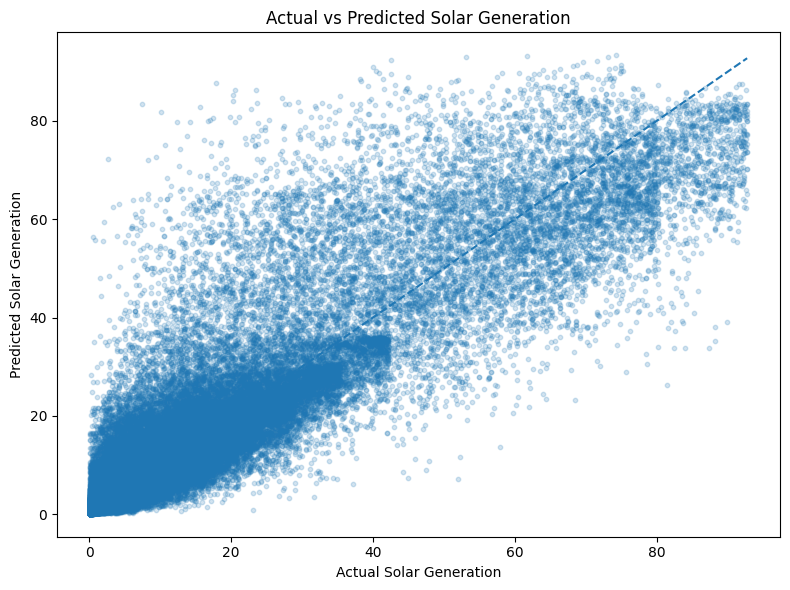

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.2,
    s=10
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Solar Generation")
plt.ylabel("Predicted Solar Generation")
plt.title("Actual vs Predicted Solar Generation")

plt.tight_layout()
plt.show()

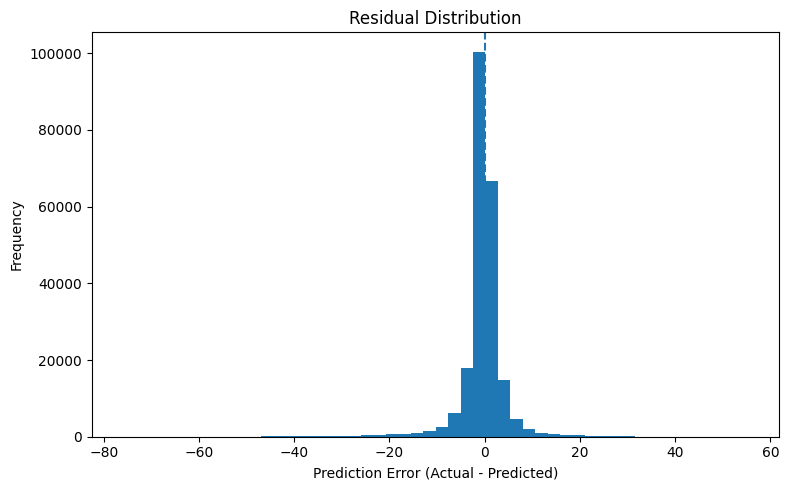

In [43]:
# Calculate prediction errors
residuals = y_test - y_pred_tuned

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=50)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

In [44]:
import joblib

joblib.dump(tuned_rf, "../tuned_random_forest_model.pkl")

print("Tuned Random Forest saved successfully!")

Tuned Random Forest saved successfully!


Model: Random Forest Regressor

n_estimators      = 50

max_depth         = 20

min_samples_split = 2

min_samples_leaf  = 1

MAE  = 2.4706

MSE  = 26.0050

RMSE = 5.0995
R²   = 0.8339


In [45]:
import joblib

loaded_model = joblib.load("../tuned_random_forest_model.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestRegressor'>
